In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


In [ ]:
file_path = "Case Study Power BI - data.xlsx"

xls = pd.ExcelFile(file_path)
print(xls.sheet_names)

['10MIN', 'Manufacturer Power Curves']


In [12]:
df = pd.read_excel(file_path, sheet_name="10MIN", header=4)



In [13]:
df.head()
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   PCTimeStamp                         52560 non-null  datetime64[ns]
 1   T04_Grid Production Power Avg. (1)  52197 non-null  float64       
 2   T05_Grid Production Power Avg. (2)  52056 non-null  float64       
 3   T06_Grid Production Power Avg. (3)  52197 non-null  float64       
 4   T07_Grid Production Power Avg. (4)  52203 non-null  float64       
 5   T08_Grid Production Power Avg. (5)  52204 non-null  float64       
 6   T09_Grid Production Power Avg. (6)  52178 non-null  float64       
 7   T10_Grid Production Power Avg. (7)  52203 non-null  float64       
 8   T11_Grid Production Power Avg. (8)  52201 non-null  float64       
 9   T12_Grid Production Power Avg. (9)  52008 non-null  float64       
 10  T04_Ambient WindSpeed 

,PCTimeStamp,T04_Grid Production Power Avg. (1),T05_Grid Production Power Avg. (2),T06_Grid Production Power Avg. (3),T07_Grid Production Power Avg. (4),T08_Grid Production Power Avg. (5),T09_Grid Production Power Avg. (6),T10_Grid Production Power Avg. (7),T11_Grid Production Power Avg. (8),T12_Grid Production Power Avg. (9),T04_Ambient WindSpeed Avg. (10),T05_Ambient WindSpeed Avg. (11),T06_Ambient WindSpeed Avg. (12),T07_Ambient WindSpeed Avg. (13),T08_Ambient WindSpeed Avg. (14),T09_Ambient WindSpeed Avg. (15),T10_Ambient WindSpeed Avg. (16),T11_Ambient WindSpeed Avg. (17),T12_Ambient WindSpeed Avg. (18)
count,52560,52197.000000,52056.000000,52197.000000,52203.000000,52204.000000,52178.000000,52203.000000,52201.000000,52008.000000,52197.000000,52056.000000,52197.000000,52203.000000,52204.000000,52178.000000,52203.00000,52201.000000,52008.000000
mean,2023-07-02 11:55:00,491.957312,517.664846,583.897182,561.920518,558.021841,484.636295,475.774206,393.463031,457.174971,5.783415,6.278825,6.573167,6.456370,6.675977,6.083029,5.76377,5.190286,5.441188
min,2023-01-01 00:00:00,-23.500000,-26.100000,-26.100000,-25.300000,-26.300000,-25.200000,-24.100000,-24.500000,-26.500000,0.000000,0.500000,0.500000,0.400000,0.400000,0.500000,0.40000,0.400000,0.500000
25%,2023-04-02 05:57:30,-3.500000,-2.600000,5.200000,-3.800000,1.900000,-3.700000,-3.800000,-3.800000,-6.100000,3.300000,3.400000,3.500000,3.300000,3.600000,3.400000,3.20000,2.800000,3.000000
50%,2023-07-02 11:55:00,168.100000,178.600000,237.900000,168.500000,233.900000,156.300000,136.600000,98.000000,146.900000,4.900000,5.300000,5.600000,5.200000,5.600000,5.000000,4.60000,4.100000,4.600000
75%,2023-10-01 17:52:30,790.600000,848.525000,1042.000000,1029.650000,938.600000,733.375000,700.000000,526.600000,694.825000,7.600000,8.300000,8.800000,8.800000,8.800000,7.900000,7.40000,6.700000,7.200000
max,2023-12-31 23:50:00,2001.300000,2000.500000,2001.000000,2001.000000,2001.000000,2000.500000,2000.800000,2000.800000,2000.900000,25.300000,25.800000,31.100000,29.700000,31.300000,32.500000,32.20000,29.500000,28.100000
std,NaN,646.701583,673.127181,704.496568,715.174062,681.407224,657.767006,661.323863,589.768263,625.871733,3.327552,3.727856,3.935941,4.056741,4.131462,3.773219,3.63616,3.465554,3.326801


There are empty values.

All turbines have the same power, because its stadistical values are similar. Max power is round 2000kW.

In [ ]:
#Cleaning data
 
# Parse timestamp
df['PCTimeStamp'] = pd.to_datetime(df['PCTimeStamp'], errors='coerce')

# Drop rows with no timestamp
df = df.dropna(subset=['PCTimeStamp']).sort_values('PCTimeStamp').reset_index(drop=True)

In [ ]:
# Basic statistics

print("Rows:", len(df))
print("Date range:", df['PCTimeStamp'].min(), "→", df['PCTimeStamp'].max())
print("Missing values per column:")
print(df.isna().sum())

Rows: 52560
Date range: 2023-01-01 00:00:00 → 2023-12-31 23:50:00
Missing values per column:
PCTimeStamp                             0
T04_Grid Production Power Avg. (1)    363
T05_Grid Production Power Avg. (2)    504
T06_Grid Production Power Avg. (3)    363
T07_Grid Production Power Avg. (4)    357
T08_Grid Production Power Avg. (5)    356
T09_Grid Production Power Avg. (6)    382
T10_Grid Production Power Avg. (7)    357
T11_Grid Production Power Avg. (8)    359
T12_Grid Production Power Avg. (9)    552
T04_Ambient WindSpeed Avg. (10)       363
T05_Ambient WindSpeed Avg. (11)       504
T06_Ambient WindSpeed Avg. (12)       363
T07_Ambient WindSpeed Avg. (13)       357
T08_Ambient WindSpeed Avg. (14)       356
T09_Ambient WindSpeed Avg. (15)       382
T10_Ambient WindSpeed Avg. (16)       357
T11_Ambient WindSpeed Avg. (17)       359
T12_Ambient WindSpeed Avg. (18)       552
dtype: int64


In [ ]:
# Identify turbines

power_cols = [c for c in df.columns if 'Grid Production Power' in c]
wind_cols = [c for c in df.columns if 'Ambient WindSpeed' in c]

turbines = sorted(set([c.split('_')[0] for c in power_cols]))
print("Turbines:", turbines)


Turbines: ['T04', 'T05', 'T06', 'T07', 'T08', 'T09', 'T10', 'T11', 'T12']


In [19]:
# Summary statistics per turbine

summary = []
for t in turbines:
    p = [c for c in power_cols if t in c][0]
    w = [c for c in wind_cols if t in c][0]
    summary.append({
        'Turbine': t,
        'Avg_Power': df[p].mean(),
        'Max_Power': df[p].max(),
        'Avg_WindSpeed': df[w].mean(),
        'Max_WindSpeed': df[w].max()
    })
pd.DataFrame(summary)


,Turbine,Avg_Power,Max_Power,Avg_WindSpeed,Max_WindSpeed
0,T04,491.957312,2001.3,5.783415,25.3
1,T05,517.664846,2000.5,6.278825,25.8
2,T06,583.897182,2001.0,6.573167,31.1
3,T07,561.920518,2001.0,6.456370,29.7
4,T08,558.021841,2001.0,6.675977,31.3
5,T09,484.636295,2000.5,6.083029,32.5
6,T10,475.774206,2000.8,5.763770,32.2
7,T11,393.463031,2000.8,5.190286,29.5
8,T12,457.174971,2000.9,5.441188,28.1


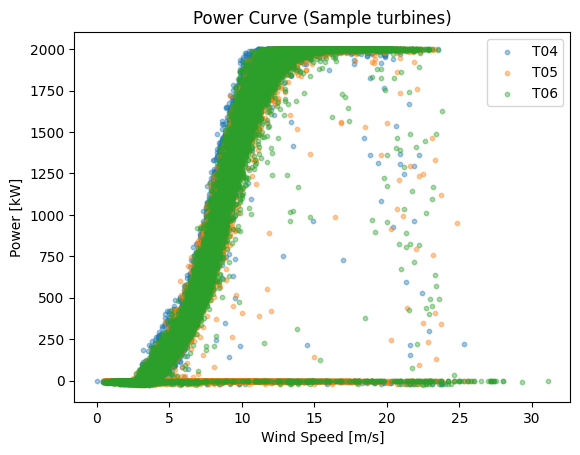

In [20]:
# Quick visual sanity check

for t in turbines[:3]:
    p = [c for c in power_cols if t in c][0]
    w = [c for c in wind_cols if t in c][0]
    plt.scatter(df[w], df[p], s=10, alpha=0.4, label=t)

plt.xlabel("Wind Speed [m/s]")
plt.ylabel("Power [kW]")
plt.legend()
plt.title("Power Curve (Sample turbines)")
plt.show()


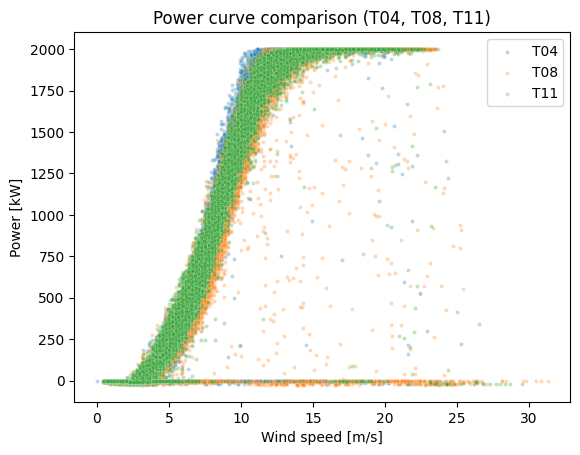

In [23]:
import seaborn as sns
for t in ["T04","T08","T11"]:
    p = [c for c in df.columns if t+"_Grid" in c][0]
    w = [c for c in df.columns if t+"_Ambient" in c][0]
    sns.scatterplot(x=df[w], y=df[p], s=8, alpha=0.3, label=t)

plt.xlabel("Wind speed [m/s]")
plt.ylabel("Power [kW]")
plt.title("Power curve comparison (T04, T08, T11)")
plt.legend()
plt.show()


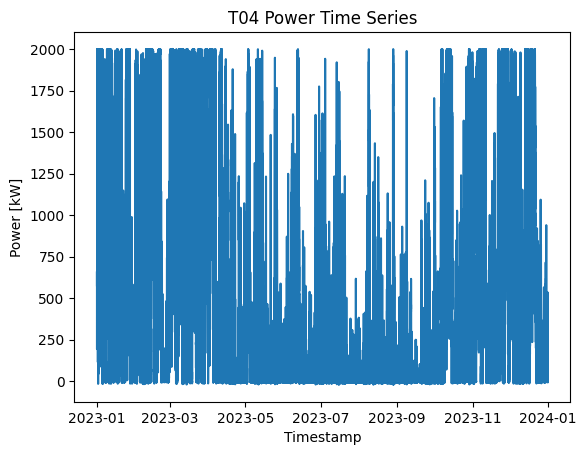

In [21]:
t = 'T04'
p = [c for c in power_cols if t in c][0]
plt.plot(df['PCTimeStamp'], df[p])
plt.title(f"{t} Power Time Series")
plt.ylabel("Power [kW]")
plt.xlabel("Timestamp")
plt.show()


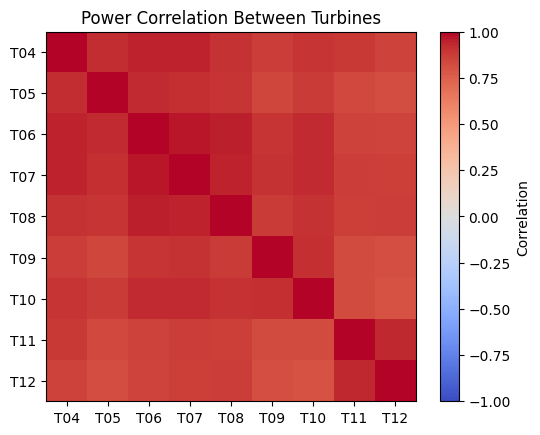

In [22]:
# Check correlation between turbines

power_df = df[power_cols]
corr = power_df.corr()
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title('Power Correlation Between Turbines')
plt.xticks(range(len(power_cols)), [c[:3] for c in power_cols])
plt.yticks(range(len(power_cols)), [c[:3] for c in power_cols])
plt.show()


Conclusions:

Rows: 52 560 → exactly one year of 10-minute data (≈ 365 days × 24 h × 6 intervals = 52 560).

Date range: 2023-01-01 → 2023-12-31 23:50.

Nulls: ≈ 0.7 – 1 % per turbine → negligible, can be ignored.

Negative power values: minimum ≈ -26 kW → probably measurement noise when turbine is idling or exporting reactive power. We’ll set these to 0.

Metric	Interpretation
Avg wind speed 5.2–6.7 m/s	Reasonable for a mid-wind site; T08 highest.
Max wind speed 25–32 m/s	Matches cut-out range → sensors OK.

Avg power ≈ 400–580 kW

T11 is a clear under-performer (≈ 393 kW vs 550–580 kW peers).	
T09, T10 also slightly below fleet average.	

In [26]:
# Replace negatives with 0
df[df.select_dtypes(float).columns] = df.select_dtypes(float).clip(lower=0)

#dropna rows if any
df = df.dropna().reset_index(drop=True)
